In [1]:
import yfinance as yf

sbi = yf.Ticker("SBIN.NS")
print(sbi.info.get('longName'))
print(sbi.history(period="1y").head())

State Bank of India
                                 Open        High         Low       Close  \
Date                                                                        
2025-09-23 00:00:00+05:30  839.468476  858.770578  836.128712  855.185181   
2025-09-24 00:00:00+05:30  860.489629  864.909953  849.144145  850.863159   
2025-09-25 00:00:00+05:30  851.206940  854.743235  844.723823  845.902588   
2025-09-26 00:00:00+05:30  846.737490  849.045857  837.896843  841.776917   
2025-09-29 00:00:00+05:30  842.857434  858.033889  840.843743  855.332581   

                             Volume  Dividends  Stock Splits  
Date                                                          
2025-09-23 00:00:00+05:30  14357863        0.0           0.0  
2025-09-24 00:00:00+05:30  12840160        0.0           0.0  
2025-09-25 00:00:00+05:30   8678821        0.0           0.0  
2025-09-26 00:00:00+05:30   6959545        0.0           0.0  
2025-09-29 00:00:00+05:30  22641712        0.0           0.0  

In [2]:
import yfinance as yf
import pandas as pd

tickers = ["SBIN.NS", "HDFCBANK.NS", "ICICIBANK.NS", "KOTAKBANK.NS", "AXISBANK.NS"]

price_data = {}
income_stmt = {}
balance_sheet = {}

for t in tickers:
    stock = yf.Ticker(t)
    
    # Price history (2 years for better trend/volatility analysis)
    price_data[t] = stock.history(period="2y")
    
    # Financial statements (annual, last 4 years by default)
    income_stmt[t] = stock.financials
    balance_sheet[t] = stock.balance_sheet
    
    print(f"{t}: {len(price_data[t])} price rows | "
          f"{income_stmt[t].shape[1]} years income stmt | "
          f"{balance_sheet[t].shape[1]} years balance sheet")

SBIN.NS: 501 price rows | 4 years income stmt | 4 years balance sheet
HDFCBANK.NS: 501 price rows | 5 years income stmt | 4 years balance sheet
ICICIBANK.NS: 501 price rows | 5 years income stmt | 5 years balance sheet
KOTAKBANK.NS: 501 price rows | 5 years income stmt | 5 years balance sheet
AXISBANK.NS: 501 price rows | 5 years income stmt | 5 years balance sheet


In [3]:
income_stmt["SBIN.NS"]

,2026-03-31,2025-03-31,2024-03-31,2023-03-31
Tax Effect Of Unusual Items,-1.764885e+07,-4.172801e+07,-6.381952e+07,-7.254238e+07
Tax Rate For Calcs,2.412000e-01,2.571150e-01,2.531980e-01,2.498740e-01
Total Unusual Items,-7.317100e+07,-1.622930e+08,-2.520540e+08,-2.903160e+08
Total Unusual Items Excluding Goodwill,-7.317100e+07,-1.622930e+08,-2.520540e+08,-2.903160e+08
Net Income From Continuing Operation Net Minority Interest,8.329878e+11,7.756134e+11,6.708467e+11,5.564817e+11
Reconciled Depreciation,4.829718e+10,3.991477e+10,3.849124e+10,3.695599e+10
Net Interest Income,1.999278e+12,1.893694e+12,1.794525e+12,1.608638e+12
Interest Expense,3.150048e+12,3.009433e+12,2.597360e+12,1.899808e+12
Interest Income,5.149326e+12,4.903127e+12,4.391885e+12,3.508446e+12
Normalized Income,8.330433e+11,7.757339e+11,6.710349e+11,5.566995e+11


In [4]:
balance_sheet["SBIN.NS"]

,2026-03-31,2025-03-31,2024-03-31,2023-03-31
Treasury Shares Number,NaN,NaN,0.000000e+00,NaN
Ordinary Shares Number,9.230618e+09,8.924620e+09,8.924612e+09,8.924612e+09
Share Issued,9.230618e+09,8.924620e+09,8.924612e+09,8.924612e+09
Net Debt,5.977875e+11,2.529243e+12,3.130372e+12,2.028400e+12
Total Debt,7.268922e+12,6.181254e+12,5.565032e+12,5.220926e+12
Tangible Book Value,5.297252e+12,4.856171e+12,4.135332e+12,3.573930e+12
Invested Capital,1.323023e+13,1.105162e+13,9.714424e+12,8.810239e+12
Net Tangible Assets,5.297252e+12,4.856171e+12,4.135332e+12,3.573930e+12
Common Stock Equity,5.961309e+12,4.870368e+12,4.149392e+12,3.589313e+12
Total Capitalization,1.323023e+13,1.105162e+13,9.714424e+12,8.810239e+12


In [5]:
rows_income = ["Total Revenue", "Net Income", "Interest Income", 
               "Interest Expense", "Net Interest Income", 
               "Operating Expense", "Diluted EPS"]

rows_balance = ["Total Assets", "Total Debt", "Stockholders Equity", 
                "Net Loan", "Cash And Cash Equivalents"]

all_data = []

for t in tickers:
    inc = income_stmt[t]
    bal = balance_sheet[t]
    
    for year in inc.columns:
        row = {"Ticker": t, "Year": year.year}
        for r in rows_income:
            row[r] = inc.loc[r, year] if r in inc.index else None
        for r in rows_balance:
            if year in bal.columns and r in bal.index:
                row[r] = bal.loc[r, year]
            else:
                row[r] = None
        all_data.append(row)

fundamentals_df = pd.DataFrame(all_data)
fundamentals_df

,Ticker,Year,Total Revenue,Net Income,Interest Income,Interest Expense,Net Interest Income,Operating Expense,Diluted EPS,Total Assets,Total Debt,Stockholders Equity,Net Loan,Cash And Cash Equivalents
0,SBIN.NS,2026,3.817092e+12,8.329878e+11,5.149326e+12,3.150048e+12,1.999278e+12,2.573940e+12,91.160,8.321569e+13,7.268922e+12,5.961309e+12,4.668151e+13,6.671135e+12
1,SBIN.NS,2025,3.495234e+12,7.756134e+11,4.903127e+12,3.009433e+12,1.893694e+12,2.328766e+12,86.910,7.314185e+13,6.181254e+12,4.870368e+12,4.003902e+13,6.208492e+12
2,SBIN.NS,2024,3.236135e+12,6.708467e+11,4.391885e+12,2.597360e+12,1.794525e+12,2.288146e+12,75.170,6.733779e+13,5.565032e+12,4.149392e+12,3.564080e+13,5.975678e+12
3,SBIN.NS,2023,2.703369e+12,5.564817e+11,3.508446e+12,1.899808e+12,1.608638e+12,1.861696e+12,62.350,5.954418e+13,5.220926e+12,3.589313e+12,3.084837e+13,5.369031e+12
4,HDFCBANK.NS,2026,1.925668e+12,7.047934e+11,3.360265e+12,1.860496e+12,1.499770e+12,NaN,45.750,5.262119e+13,6.643640e+12,8.167396e+12,3.099389e+13,3.650674e+12
5,HDFCBANK.NS,2025,1.838641e+12,6.735083e+11,3.227963e+12,1.823477e+12,1.404486e+12,NaN,44.820,4.818767e+13,7.326106e+12,7.676891e+12,2.810298e+13,3.222323e+12
6,HDFCBANK.NS,2024,1.604968e+12,6.226566e+11,2.781926e+12,1.533923e+12,1.248003e+12,NaN,44.160,4.411857e+13,8.093552e+12,6.947327e+12,2.633570e+13,3.425973e+12
7,HDFCBANK.NS,2023,1.205375e+12,4.954469e+11,1.689527e+12,7.755382e+11,9.139885e+11,NaN,88.680,2.575562e+13,3.151793e+12,2.912201e+12,1.705293e+13,2.363920e+12
8,HDFCBANK.NS,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,ICICIBANK.NS,2026,2.234071e+12,5.420770e+11,1.952185e+12,8.902858e+11,1.061899e+12,NaN,74.770,2.914498e+13,2.076173e+12,3.630604e+12,1.599309e+13,2.902489e+12


In [6]:
# Drop rows where Net Income is missing (that's our marker for "empty year")
fundamentals_df = fundamentals_df.dropna(subset=["Net Income"]).reset_index(drop=True)

# Compute ratios
fundamentals_df["ROE"] = fundamentals_df["Net Income"] / fundamentals_df["Stockholders Equity"]
fundamentals_df["ROA"] = fundamentals_df["Net Income"] / fundamentals_df["Total Assets"]
fundamentals_df["NIM"] = fundamentals_df["Net Interest Income"] / fundamentals_df["Total Assets"]
fundamentals_df["Equity_to_Assets"] = fundamentals_df["Stockholders Equity"] / fundamentals_df["Total Assets"]
fundamentals_df["Loan_to_Assets"] = fundamentals_df["Net Loan"] / fundamentals_df["Total Assets"]

# Cost-to-Income — only where Operating Expense exists
fundamentals_df["Cost_to_Income"] = fundamentals_df["Operating Expense"] / fundamentals_df["Total Revenue"]

# EPS YoY growth (sort by ticker+year first to get correct order)
fundamentals_df = fundamentals_df.sort_values(["Ticker", "Year"]).reset_index(drop=True)
fundamentals_df["EPS_Growth_%"] = fundamentals_df.groupby("Ticker")["Diluted EPS"].pct_change() * 100

# Round for readability
ratio_cols = ["ROE", "ROA", "NIM", "Equity_to_Assets", "Loan_to_Assets", "Cost_to_Income", "EPS_Growth_%"]
fundamentals_df[ratio_cols] = fundamentals_df[ratio_cols].apply(lambda x: round(x*100, 2) if x.name != "EPS_Growth_%" else round(x, 2))

fundamentals_df[["Ticker", "Year", "ROE", "ROA", "NIM", "Equity_to_Assets", "Loan_to_Assets", "Cost_to_Income", "EPS_Growth_%"]]

,Ticker,Year,ROE,ROA,NIM,Equity_to_Assets,Loan_to_Assets,Cost_to_Income,EPS_Growth_%
0,AXISBANK.NS,2023,8.34,0.80,3.28,9.65,63.22,64.97,NaN
1,AXISBANK.NS,2024,16.80,1.74,3.38,10.34,64.74,49.19,142.61
2,AXISBANK.NS,2025,14.98,1.69,3.40,11.30,64.24,47.08,6.08
3,AXISBANK.NS,2026,12.27,1.36,3.00,11.05,64.52,50.28,-6.32
4,HDFCBANK.NS,2023,17.01,1.92,3.55,11.31,66.21,NaN,NaN
5,HDFCBANK.NS,2024,8.96,1.41,2.83,15.75,59.69,NaN,-50.20
6,HDFCBANK.NS,2025,8.77,1.40,2.91,15.93,58.32,NaN,1.49
7,HDFCBANK.NS,2026,8.63,1.34,2.85,15.52,58.90,NaN,2.07
8,ICICIBANK.NS,2023,15.87,1.74,3.60,10.95,52.80,NaN,NaN
9,ICICIBANK.NS,2024,17.28,1.87,3.61,10.83,51.21,NaN,29.52


In [7]:
print(income_stmt["HDFCBANK.NS"].index.tolist())

['Tax Effect Of Unusual Items', 'Tax Rate For Calcs', 'Total Unusual Items', 'Total Unusual Items Excluding Goodwill', 'Net Income From Continuing Operation Net Minority Interest', 'Reconciled Depreciation', 'Net Interest Income', 'Interest Expense', 'Interest Income', 'Normalized Income', 'Net Income From Continuing And Discontinued Operation', 'Diluted Average Shares', 'Basic Average Shares', 'Diluted EPS', 'Basic EPS', 'Diluted NI Availto Com Stockholders', 'Net Income Common Stockholders', 'Net Income', 'Minority Interests', 'Net Income Including Noncontrolling Interests', 'Net Income Extraordinary', 'Net Income Continuous Operations', 'Tax Provision', 'Pretax Income', 'Other Non Operating Income Expenses', 'Special Income Charges', 'Gain On Sale Of Security', 'Depreciation Amortization Depletion Income Statement', 'Depreciation And Amortization In Income Statement', 'Amortization', 'Amortization Of Intangibles Income Statement', 'Depreciation Income Statement', 'Selling General An

In [8]:
opex_components = [
    "Salaries And Wages", 
    "Occupancy And Equipment", 
    "Other Non Interest Expense", 
    "Selling General And Administration",
    "Depreciation And Amortization In Income Statement",
    "Insurance And Claims"
]

def get_operating_expense(ticker, year):
    inc = income_stmt[ticker]
    if year not in inc.columns:
        return None
    # If the bank already reports a single "Operating Expense" line, use it
    if "Operating Expense" in inc.index and pd.notna(inc.loc["Operating Expense", year]):
        return inc.loc["Operating Expense", year]
    # Otherwise, sum whichever components exist for this bank
    total = 0
    found_any = False
    for comp in opex_components:
        if comp in inc.index and pd.notna(inc.loc[comp, year]):
            total += inc.loc[comp, year]
            found_any = True
    return total if found_any else None

# Rebuild the Operating Expense column properly for every row
fundamentals_df["Operating Expense"] = fundamentals_df.apply(
    lambda row: get_operating_expense(row["Ticker"], pd.Timestamp(f"{row['Year']}-03-31")), axis=1
)

# Recompute Cost-to-Income with the fixed values
fundamentals_df["Cost_to_Income"] = round(
    fundamentals_df["Operating Expense"] / fundamentals_df["Total Revenue"] * 100, 2
)

fundamentals_df[["Ticker", "Year", "Cost_to_Income"]]

,Ticker,Year,Cost_to_Income
0,AXISBANK.NS,2023,64.97
1,AXISBANK.NS,2024,49.19
2,AXISBANK.NS,2025,47.08
3,AXISBANK.NS,2026,50.28
4,HDFCBANK.NS,2023,55.46
5,HDFCBANK.NS,2024,89.55
6,HDFCBANK.NS,2025,85.11
7,HDFCBANK.NS,2026,57.13
8,ICICIBANK.NS,2023,76.93
9,ICICIBANK.NS,2024,79.62


In [9]:
comps_by_year = income_stmt["HDFCBANK.NS"].loc[
    [c for c in opex_components if c in income_stmt["HDFCBANK.NS"].index]
]
comps_by_year

,2026-03-31,2025-03-31,2024-03-31,2023-03-31,2022-03-31
Salaries And Wages,3.185947e+11,2.992517e+11,2.887760e+11,1.997268e+11,NaN
Occupancy And Equipment,9.105530e+10,7.773360e+10,6.513150e+10,4.506990e+10,NaN
Other Non Interest Expense,NaN,NaN,7.916980e+10,NaN,NaN
Selling General And Administration,6.286905e+11,5.920094e+11,5.697968e+11,4.002198e+11,NaN
Depreciation And Amortization In Income Statement,6.183230e+10,6.302130e+10,5.234830e+10,2.348970e+10,NaN
Insurance And Claims,NaN,5.328671e+11,3.819658e+11,0.000000e+00,0.0


In [10]:
def get_operating_expense(ticker, year):
    inc = income_stmt[ticker]
    if year not in inc.columns:
        return None
    # Prefer a single reported "Operating Expense" line if it exists
    if "Operating Expense" in inc.index and pd.notna(inc.loc["Operating Expense", year]):
        return inc.loc["Operating Expense", year]
    # Otherwise use the aggregate SG&A line alone (don't sum its own sub-components)
    if "Selling General And Administration" in inc.index and pd.notna(inc.loc["Selling General And Administration", year]):
        return inc.loc["Selling General And Administration", year]
    return None

fundamentals_df["Operating Expense"] = fundamentals_df.apply(
    lambda row: get_operating_expense(row["Ticker"], pd.Timestamp(f"{row['Year']}-03-31")), axis=1
)

fundamentals_df["Cost_to_Income"] = round(
    fundamentals_df["Operating Expense"] / fundamentals_df["Total Revenue"] * 100, 2
)

fundamentals_df[["Ticker", "Year", "Cost_to_Income"]]

,Ticker,Year,Cost_to_Income
0,AXISBANK.NS,2023,64.97
1,AXISBANK.NS,2024,49.19
2,AXISBANK.NS,2025,47.08
3,AXISBANK.NS,2026,50.28
4,HDFCBANK.NS,2023,33.20
5,HDFCBANK.NS,2024,35.50
6,HDFCBANK.NS,2025,32.20
7,HDFCBANK.NS,2026,32.65
8,ICICIBANK.NS,2023,22.27
9,ICICIBANK.NS,2024,22.97


In [11]:
# Rename for clarity in all downstream outputs
fundamentals_df = fundamentals_df.rename(
    columns={"Cost_to_Income": "Cost_to_Income_pct"}
)

# Track which basis was used per bank, for the footnote
opex_basis = {
    "SBIN.NS": "Operating Expense (reported)",
    "KOTAKBANK.NS": "Operating Expense (reported)",
    "AXISBANK.NS": "Operating Expense (reported)",
    "HDFCBANK.NS": "Selling General & Administration (proxy)",
    "ICICIBANK.NS": "Selling General & Administration (proxy)"
}
fundamentals_df["Cost_Basis"] = fundamentals_df["Ticker"].map(opex_basis)

print("⚠ Note: Cost-to-Income for HDFC/ICICI uses SG&A as a proxy for operating "
      "expense (their statements don't report a single 'Operating Expense' line). "
      "This may understate their true cost base vs. SBI/Kotak/Axis, which report "
      "operating expense directly. Treat cross-bank Cost-to-Income comparisons "
      "with this caveat; within-bank trends over time remain valid.")

fundamentals_df[["Ticker", "Year", "Cost_to_Income_pct", "Cost_Basis"]]

⚠ Note: Cost-to-Income for HDFC/ICICI uses SG&A as a proxy for operating expense (their statements don't report a single 'Operating Expense' line). This may understate their true cost base vs. SBI/Kotak/Axis, which report operating expense directly. Treat cross-bank Cost-to-Income comparisons with this caveat; within-bank trends over time remain valid.


,Ticker,Year,Cost_to_Income_pct,Cost_Basis
0,AXISBANK.NS,2023,64.97,Operating Expense (reported)
1,AXISBANK.NS,2024,49.19,Operating Expense (reported)
2,AXISBANK.NS,2025,47.08,Operating Expense (reported)
3,AXISBANK.NS,2026,50.28,Operating Expense (reported)
4,HDFCBANK.NS,2023,33.20,Selling General & Administration (proxy)
5,HDFCBANK.NS,2024,35.50,Selling General & Administration (proxy)
6,HDFCBANK.NS,2025,32.20,Selling General & Administration (proxy)
7,HDFCBANK.NS,2026,32.65,Selling General & Administration (proxy)
8,ICICIBANK.NS,2023,22.27,Selling General & Administration (proxy)
9,ICICIBANK.NS,2024,22.97,Selling General & Administration (proxy)


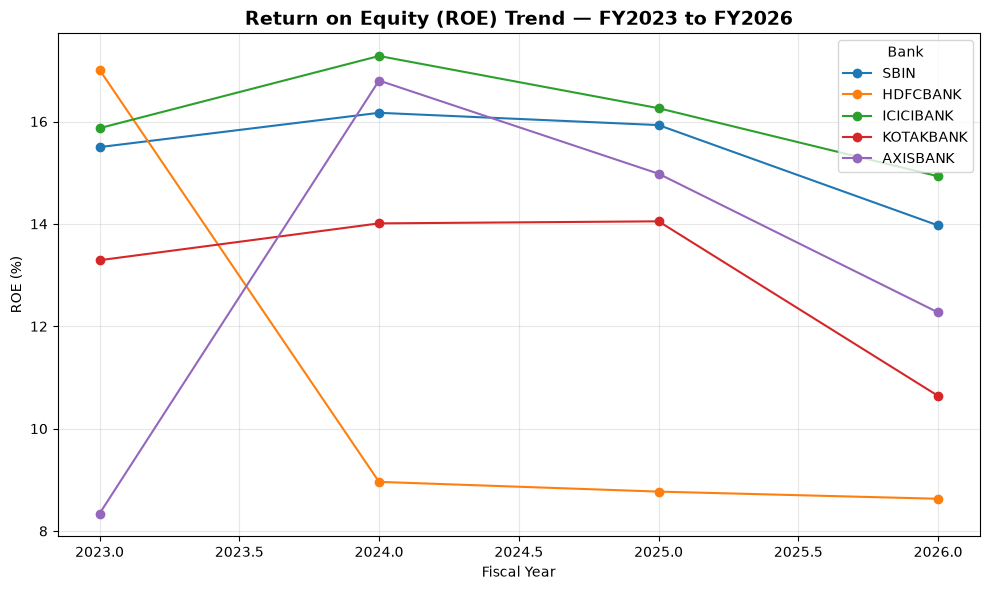

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

for ticker in tickers:
    bank_data = fundamentals_df[fundamentals_df["Ticker"] == ticker].sort_values("Year")
    ax.plot(bank_data["Year"], bank_data["ROE"], marker='o', label=ticker.replace(".NS", ""))

ax.set_title("Return on Equity (ROE) Trend — FY2023 to FY2026", fontsize=14, fontweight='bold')
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("ROE (%)")
ax.legend(title="Bank")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/roe_trend.png", dpi=150)
plt.show()

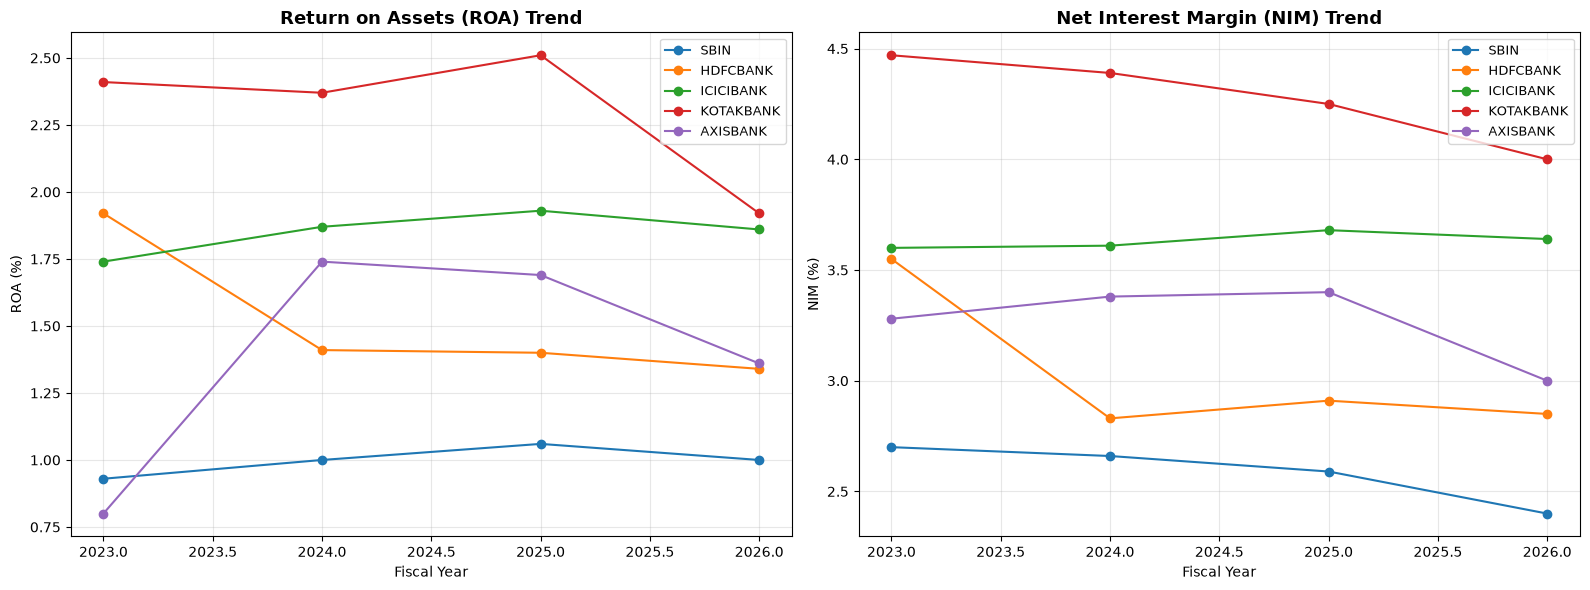

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROA trend
for ticker in tickers:
    bank_data = fundamentals_df[fundamentals_df["Ticker"] == ticker].sort_values("Year")
    axes[0].plot(bank_data["Year"], bank_data["ROA"], marker='o', label=ticker.replace(".NS", ""))
axes[0].set_title("Return on Assets (ROA) Trend", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Fiscal Year")
axes[0].set_ylabel("ROA (%)")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# NIM trend
for ticker in tickers:
    bank_data = fundamentals_df[fundamentals_df["Ticker"] == ticker].sort_values("Year")
    axes[1].plot(bank_data["Year"], bank_data["NIM"], marker='o', label=ticker.replace(".NS", ""))
axes[1].set_title("Net Interest Margin (NIM) Trend", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Fiscal Year")
axes[1].set_ylabel("NIM (%)")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/roa_nim_trend.png", dpi=150)
plt.show()

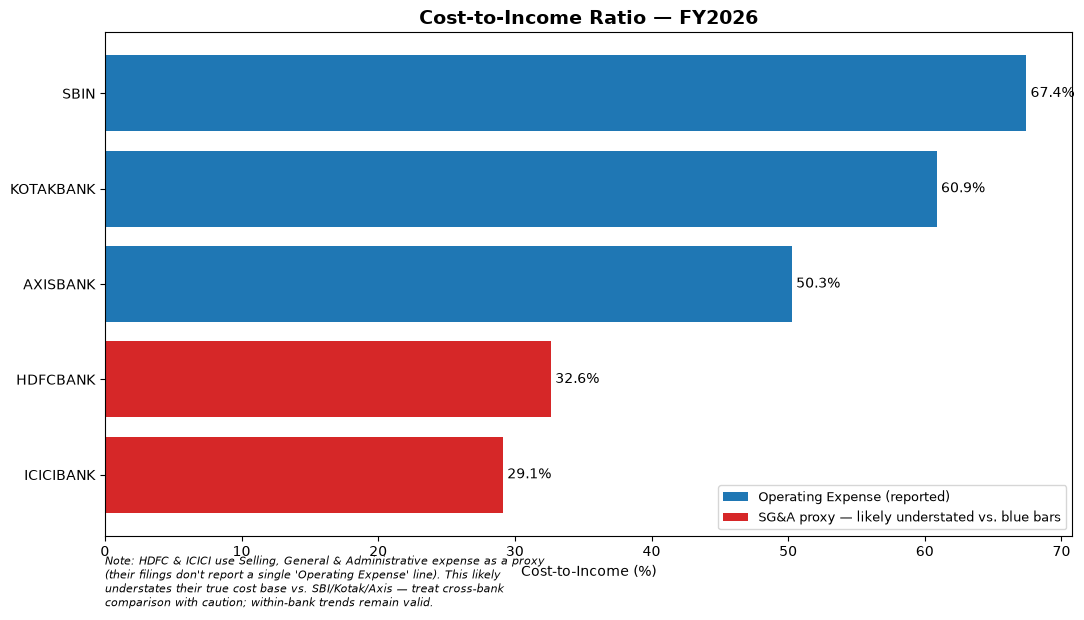

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))

latest_year = fundamentals_df["Year"].max()
latest_data = fundamentals_df[fundamentals_df["Year"] == latest_year].sort_values("Cost_to_Income_pct")

colors = ['#d62728' if basis.startswith("Selling") else '#1f77b4' 
          for basis in latest_data["Cost_Basis"]]

bars = ax.barh(latest_data["Ticker"].str.replace(".NS", ""), 
                latest_data["Cost_to_Income_pct"], color=colors)

ax.set_title(f"Cost-to-Income Ratio — FY{latest_year}", fontsize=14, fontweight='bold')
ax.set_xlabel("Cost-to-Income (%)")
ax.bar_label(bars, fmt='%.1f%%', padding=3)

# Legend for the caveat
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1f77b4', label='Operating Expense (reported)'),
    Patch(facecolor='#d62728', label='SG&A proxy — likely understated vs. blue bars')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.figtext(0.1, -0.02, 
    "Note: HDFC & ICICI use Selling, General & Administrative expense as a proxy\n"
    "(their filings don't report a single 'Operating Expense' line). This likely\n"
    "understates their true cost base vs. SBI/Kotak/Axis — treat cross-bank\n"
    "comparison with caution; within-bank trends remain valid.",
    fontsize=8, style='italic', ha='left')

plt.tight_layout()
plt.savefig("outputs/cost_to_income.png", dpi=150, bbox_inches='tight')
plt.show()

In [15]:
latest = fundamentals_df[fundamentals_df["Year"] == latest_year].copy()

def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

latest["ROE_score"] = normalize(latest["ROE"])
latest["ROA_score"] = normalize(latest["ROA"])
latest["NIM_score"] = normalize(latest["NIM"])
latest["Equity_score"] = normalize(latest["Equity_to_Assets"])

# Cost-to-Income: only score the 3 banks with a comparable basis; others get a neutral 0.5
reported_mask = latest["Cost_Basis"] == "Operating Expense (reported)"
latest["CostEff_score"] = 0.5  # neutral default
latest.loc[reported_mask, "CostEff_score"] = 1 - normalize(latest.loc[reported_mask, "Cost_to_Income_pct"])

latest["Health_Score"] = (
    0.25 * latest["ROE_score"] +
    0.25 * latest["ROA_score"] +
    0.20 * latest["NIM_score"] +
    0.15 * latest["Equity_score"] +
    0.15 * latest["CostEff_score"]
) * 100

latest[["Ticker", "Health_Score"]].sort_values("Health_Score", ascending=False)

,Ticker,Health_Score
11,ICICIBANK.NS,78.663143
15,KOTAKBANK.NS,73.705053
3,AXISBANK.NS,52.080264
7,HDFCBANK.NS,33.868718
19,SBIN.NS,21.190476


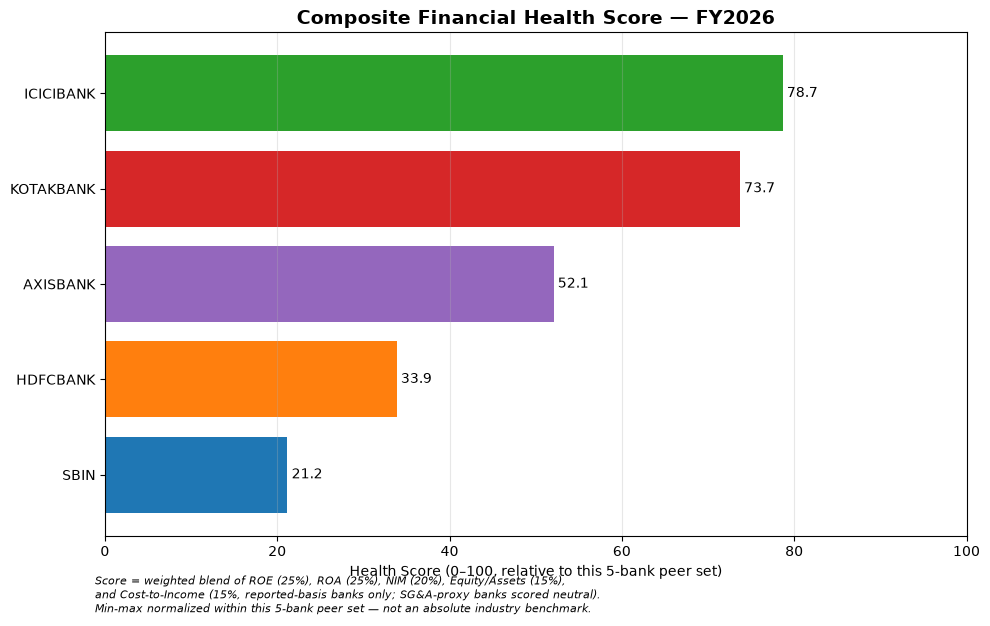

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

ranked = latest.sort_values("Health_Score", ascending=True)
colors_map = {"ICICIBANK.NS": "#2ca02c", "KOTAKBANK.NS": "#d62728", 
              "AXISBANK.NS": "#9467bd", "HDFCBANK.NS": "#ff7f0e", "SBIN.NS": "#1f77b4"}
bar_colors = [colors_map[t] for t in ranked["Ticker"]]

bars = ax.barh(ranked["Ticker"].str.replace(".NS", ""), ranked["Health_Score"], color=bar_colors)

ax.set_title(f"Composite Financial Health Score — FY{latest_year}", fontsize=14, fontweight='bold')
ax.set_xlabel("Health Score (0–100, relative to this 5-bank peer set)")
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.set_xlim(0, 100)
ax.grid(alpha=0.3, axis='x')

plt.figtext(0.1, -0.03,
    "Score = weighted blend of ROE (25%), ROA (25%), NIM (20%), Equity/Assets (15%),\n"
    "and Cost-to-Income (15%, reported-basis banks only; SG&A-proxy banks scored neutral).\n"
    "Min-max normalized within this 5-bank peer set — not an absolute industry benchmark.",
    fontsize=8, style='italic', ha='left')

plt.tight_layout()
plt.savefig("outputs/health_score.png", dpi=150, bbox_inches='tight')
plt.show()

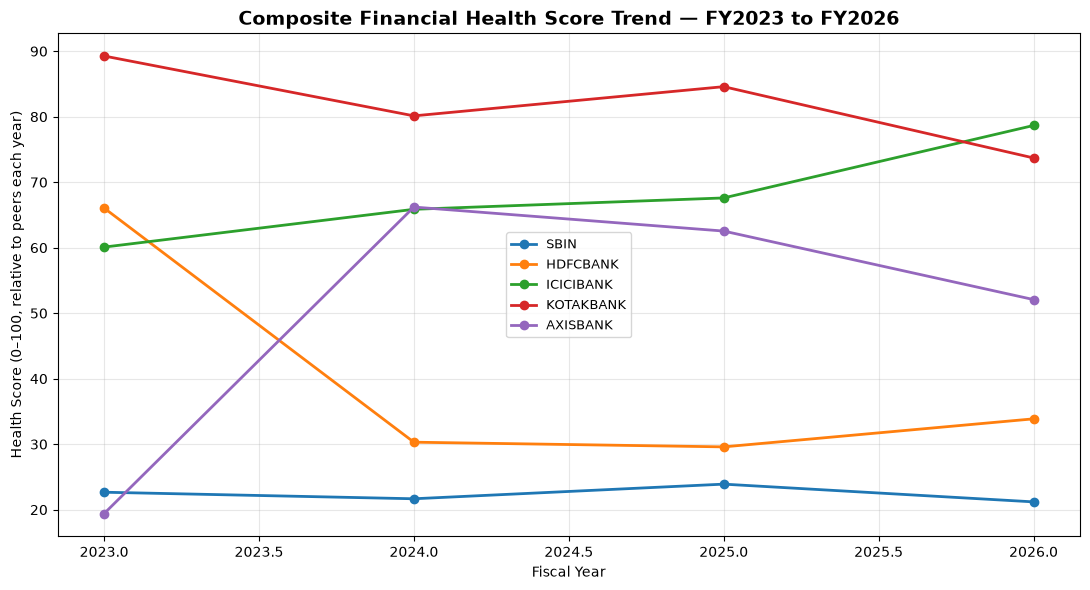

Ticker,AXISBANK.NS,HDFCBANK.NS,ICICIBANK.NS,KOTAKBANK.NS,SBIN.NS
Year,,,,,
2023,19.4,66.1,60.1,89.3,22.7
2024,66.2,30.3,65.9,80.1,21.7
2025,62.5,29.6,67.6,84.6,23.9
2026,52.1,33.9,78.7,73.7,21.2


In [17]:
def compute_health_scores_by_year(df):
    all_scores = []
    for year in sorted(df["Year"].unique()):
        year_data = df[df["Year"] == year].copy()
        if len(year_data) < 2:
            continue  # need at least 2 banks to normalize meaningfully
        
        year_data["ROE_score"] = normalize(year_data["ROE"])
        year_data["ROA_score"] = normalize(year_data["ROA"])
        year_data["NIM_score"] = normalize(year_data["NIM"])
        year_data["Equity_score"] = normalize(year_data["Equity_to_Assets"])
        
        reported_mask = year_data["Cost_Basis"] == "Operating Expense (reported)"
        year_data["CostEff_score"] = 0.5
        if reported_mask.sum() >= 2:
            year_data.loc[reported_mask, "CostEff_score"] = 1 - normalize(year_data.loc[reported_mask, "Cost_to_Income_pct"])
        
        year_data["Health_Score"] = (
            0.25 * year_data["ROE_score"] +
            0.25 * year_data["ROA_score"] +
            0.20 * year_data["NIM_score"] +
            0.15 * year_data["Equity_score"] +
            0.15 * year_data["CostEff_score"]
        ) * 100
        
        all_scores.append(year_data[["Ticker", "Year", "Health_Score"]])
    
    return pd.concat(all_scores, ignore_index=True)

health_trend = compute_health_scores_by_year(fundamentals_df)

fig, ax = plt.subplots(figsize=(11, 6))
for ticker in tickers:
    bank_scores = health_trend[health_trend["Ticker"] == ticker].sort_values("Year")
    ax.plot(bank_scores["Year"], bank_scores["Health_Score"], marker='o', 
            label=ticker.replace(".NS", ""), color=colors_map[ticker], linewidth=2)

ax.set_title("Composite Financial Health Score Trend — FY2023 to FY2026", fontsize=14, fontweight='bold')
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Health Score (0–100, relative to peers each year)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/health_score_trend.png", dpi=150)
plt.show()

health_trend.pivot(index="Year", columns="Ticker", values="Health_Score").round(1)

In [18]:
fundamentals_df.to_csv("data/bank_fundamentals.csv", index=False)
health_trend.to_csv("data/health_score_trend.csv", index=False)

In [19]:
import os
os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

In [20]:
fundamentals_df.to_csv("data/bank_fundamentals.csv", index=False)
health_trend.to_csv("data/health_score_trend.csv", index=False)